In [11]:
%matplotlib widget
import torch
import decord
decord.bridge.set_bridge("torch")
from PIL import Image

from dift.visualization import Demo

In [12]:
video_path = "data/dance/videos/dance-jump.mp4"
video_reader = decord.VideoReader(video_path, height=720, width=720)
batch_ids = torch.linspace(0, len(video_reader) - 1, 13)
frames = video_reader.get_batch(batch_ids)
frames.shape

torch.Size([13, 720, 720, 3])

In [13]:
images = []
for i in range(len(frames)):
    image = Image.fromarray(frames[i].numpy())
    assert image.mode == "RGB"
    images.append(image)

print(images[0].size, images[0].mode)

(720, 720) RGB


In [14]:
ft = torch.load("dift.pt")
print(ft.shape)
image_size = (480, 720)

demo = Demo(images[:4], ft[:4], 720)

torch.Size([13, 16, 60, 90])


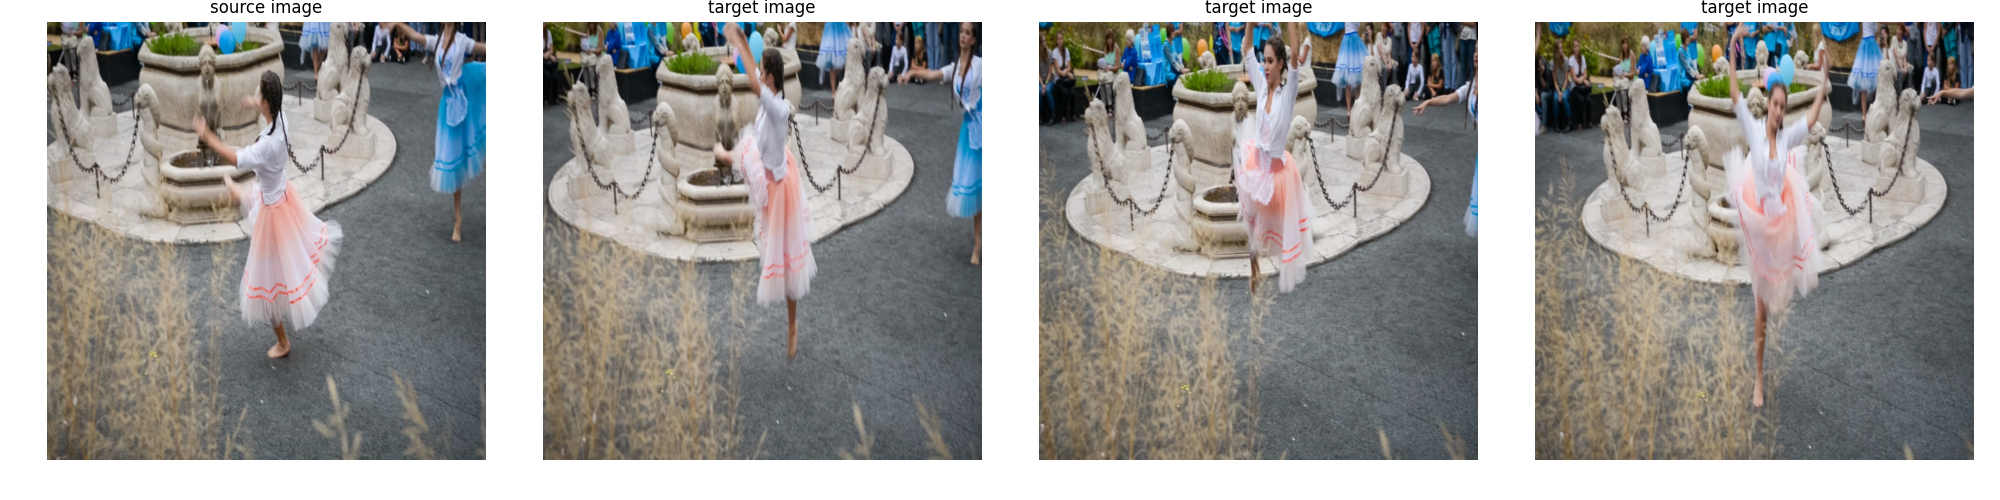

In [15]:
demo.plot_img_pairs(fig_size=5)